In [1]:
import cobra
import pandas as pd
from tabulate import tabulate
import matplotlib.ticker as ticker
import matplotlib.pyplot as plt
import numpy as np

In [2]:

model = cobra.io.read_sbml_model("/home/lbabo/PlantsSM/vitis_vinifera/proteome_annotation/iMS7199.xml")
df_prot_raw = pd.read_csv("/home/lbabo/PlantsSM/vitis_vinifera/proteome_annotation/parse_and_stats/parsed_predictions_PN40024_v41_protbert_fasta.csv")


In [9]:
print(f"Modelo: {model.id}")
print(f"Número de reações: {len(model.reactions)}")
print(f"Número de metabolitos: {len(model.metabolites)}")
print(f"Número de genes: {len(model.genes)}")

Modelo: vvinif2023
Número de reações: 5399
Número de metabolitos: 5143
Número de genes: 7199


In [3]:
records = []
for rxn in model.reactions:
    ecs = rxn.annotation.get("ec-code", [])
    
    if isinstance(ecs, str):
        ecs = [ecs]
        
    for ec in ecs:
        ec_clean = ec.replace("EC-", "").strip()
        for gene in rxn.genes:
            gene_id = gene.id[2:] if gene.id.startswith("G_") else gene.id
            records.append({"gene": gene_id, "ec_modelo": ec_clean})

df_modelo = pd.DataFrame(records).drop_duplicates()


LIMIAR_PROBABILIDADE = 0.5

rows = []
for _, row in df_prot_raw.iterrows():
    gene_id = str(row["id"]).strip()
    
    for nivel, col_ec in enumerate(["EC1", "EC2", "EC3", "EC4"], start=1):
        col_prob = f"prob_{col_ec}" # Constrói o nome "prob_EC1", "prob_EC2", etc.
        
        val_ec = str(row.get(col_ec, "") or "").strip()
        val_prob = str(row.get(col_prob, "") or "").strip()
        
        if not val_ec or val_ec == "nan":
            continue
            
        lista_ecs = val_ec.split("|")
        lista_probs = val_prob.split("|") if val_prob and val_prob != "nan" else []
        
        for i, ec in enumerate(lista_ecs):
            ec = ec.strip()
            if not ec:
                continue
            prob = float(lista_probs[i]) if i < len(lista_probs) else 0.0    
            if prob >= LIMIAR_PROBABILIDADE:
                rows.append({"gene": gene_id, "ec_prot": ec, "nivel_anotado": nivel})

df_prot = pd.DataFrame(rows).drop_duplicates()
print(f"(threshold >= {LIMIAR_PROBABILIDADE})")
print("\n")

genes_modelo = set(df_modelo['gene'])
genes_prot = set(df_prot['gene'])

genes_em_comum = genes_modelo.intersection(genes_prot)
genes_so_no_prot = genes_prot - genes_modelo
genes_so_no_modelo = genes_modelo - genes_prot

print(f"Total de enzimas no Modelo iMS7199:                                 {len(genes_modelo)}")
print(f"Total de enzimas com EC na previsão (ProtBERT):                     {len(genes_prot)}")
print(f"Enzimas partilhadas por ambos (Modelo iMS7199 e Previsão ProtBERT): {len(genes_em_comum)}")
print(f"Enzimas novas (Apenas presentes na previsão ProtBERT):              {len(genes_so_no_prot)}")
print(f"Enzimas não previstas (Presentes unicamente no Modelo iMS7199):     {len(genes_so_no_modelo)}")
print("\n")

df_merge = pd.merge(df_modelo, df_prot, on="gene", how="inner")

def prefixo(ec, n):
    if pd.isna(ec): return None
    partes = str(ec).split(".")
    return ".".join(partes[:n]) if len(partes) >= n else None

resultados = []

for nivel in [1, 2, 3, 4]:
    df_merge[f'ec_mod_L{nivel}'] = df_merge['ec_modelo'].apply(lambda x: prefixo(x, nivel))
    df_merge[f'ec_pro_L{nivel}'] = df_merge['ec_prot'].apply(lambda x: prefixo(x, nivel))

    df_merge[f'match_L{nivel}'] = (df_merge[f'ec_mod_L{nivel}'] == df_merge[f'ec_pro_L{nivel}']) & df_merge[f'ec_mod_L{nivel}'].notna()
    
    genes_corretos = df_merge[df_merge[f'match_L{nivel}'] == True]['gene'].nunique()
    total_genes = df_merge['gene'].nunique()
    
    resultados.append({
        "Nível EC": f"Nível {nivel}",
        "Match de IDs (Modelo e previsão ProtBERT)": total_genes,
        "Match de EC numbers": genes_corretos,
        "%": round((genes_corretos / total_genes * 100), 2) if total_genes > 0 else 0
    })

df_resumo = pd.DataFrame(resultados)
print(tabulate(df_resumo, headers='keys', tablefmt='simple', stralign='center', numalign='center', showindex=False))
print("\n")

(threshold >= 0.5)


Total de enzimas no Modelo iMS7199:                                 6289
Total de enzimas com EC na previsão (ProtBERT):                     10784
Enzimas partilhadas por ambos (Modelo iMS7199 e Previsão ProtBERT): 4813
Enzimas novas (Apenas presentes na previsão ProtBERT):              5971
Enzimas não previstas (Presentes unicamente no Modelo iMS7199):     1476


 Nível EC    Match de IDs (Modelo e previsão ProtBERT)    Match de EC numbers     %
----------  -------------------------------------------  ---------------------  -----
 Nível 1                       4813                              4629           96.18
 Nível 2                       4813                              4455           92.56
 Nível 3                       4813                              4225           87.78
 Nível 4                       4813                              2639           54.83




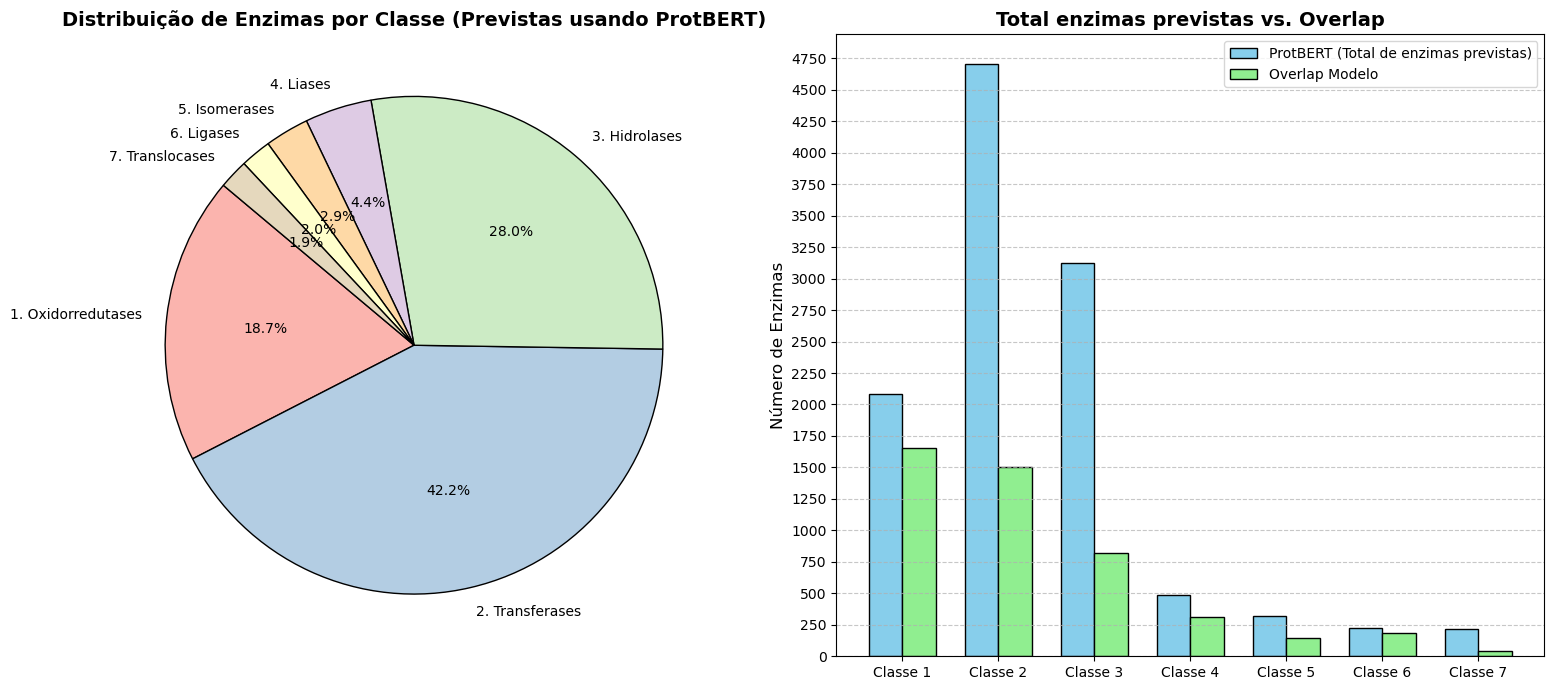

In [4]:
classes_nomes = {
    '1': '1. Oxidorredutases',
    '2': '2. Transferases',
    '3': '3. Hidrolases',
    '4': '4. Liases',
    '5': '5. Isomerases',
    '6': '6. Ligases',
    '7': '7. Translocases'
}


df_prot['classe_ec'] = df_prot['ec_prot'].astype(str).str.split('.').str[0]

genes_por_classe = df_prot[df_prot['classe_ec'].isin(classes_nomes.keys())].groupby('classe_ec')['gene'].nunique()

df_merge['classe_ec'] = df_merge['ec_pro_L1']
overlap_por_classe = df_merge[df_merge['match_L1'] == True].groupby('classe_ec')['gene'].nunique()

labels = [classes_nomes[c] for c in genes_por_classe.index]
valores_total = genes_por_classe.values
valores_overlap = [overlap_por_classe.get(c, 0) for c in genes_por_classe.index]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

cores = plt.cm.Pastel1.colors  
ax1.pie(valores_total, labels=labels, autopct='%1.1f%%', startangle=140, colors=cores, wedgeprops={'edgecolor': 'black', 'linewidth': 1})
ax1.set_title('Distribuição de Enzimas por Classe (Previstas usando ProtBERT)', fontsize=14, fontweight='bold')

x = np.arange(len(labels))
largura = 0.35

ax2.bar(x - largura/2, valores_total, largura, label='ProtBERT (Total de enzimas previstas)', color='#87CEEB', edgecolor='black')
ax2.bar(x + largura/2, valores_overlap, largura, label='Overlap Modelo', color='#90EE90', edgecolor='black')

ax2.set_ylabel('Número de Enzimas', fontsize=12)
ax2.set_title('Total enzimas previstas vs. Overlap', fontsize=14, fontweight='bold')

ax2.set_xticks(x)
ax2.set_xticklabels([f"Classe {c}" for c in genes_por_classe.index])
ax2.legend()
ax2.grid(axis='y', linestyle='--', alpha=0.7)
ax2.yaxis.set_major_locator(ticker.MaxNLocator(20))
plt.tight_layout()
plt.savefig("graficos_apresentacao.png", dpi=300, bbox_inches='tight')

In [ ]:
#para gerar um csv com as enzimas novas, presentes na previsão ProtBERT mas ausentes no modelo iMS7199

df_novos = df_prot[df_prot['gene'].isin(genes_so_no_prot)]
df_novos.to_csv("enzimas_novas_protbert_em_falta_no_modelo.csv", index=False)

In [ ]:
colunas_finais = ['ID_Gene', 'EC_modelo', 'EC_previsão_ProtBERT', 'match_Nivel_1', 'match_Nivel_2', 'match_Nivel_3', 'match_Nivel_4']
df_detalhe = df_merge[colunas_finais].drop_duplicates()
df_detalhe.to_csv("comparacao_detalhada_enzimas.csv", index=False)